# **Product Recognition of Books**

## Image Processing and Computer Vision - Assignment Module \#1

Contacts:

- Prof. Giuseppe Lisanti -> giuseppe.lisanti@unibo.it
- Prof. Samuele Salti -> samuele.salti@unibo.it
- Alex Costanzino -> alex.costanzino@unibo.it
- Francesco Ballerini -> francesco.ballerini4@unibo.it


Computer vision-based object detection techniques can be applied in library or bookstore settings to build a system that identifies books on shelves.

Such a system could assist in:

- Helping visually impaired users locate books by title/author;
- Automating inventory management (e.g., detecting misplaced or out-of-stock books);
- Enabling faster book retrieval by recognizing spine text or cover designs.


## Data

Two folders of images are provided:

- **Models**: contains one reference image for each product that the system should be able to identify;
- **Scenes**: contains different shelve pictures to test the developed algorithm in different scenarios.


In [46]:
# from google.colab import drive
# drive.mount('/content/drive')

# !cp -r /content/drive/MyDrive/dataset_ipcv/dataset.zip ./
# !unzip dataset.zip

In [47]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

# Set latex font for plots cmu
plt.rcParams["font.family"] = "cmr10"
plt.rcParams["font.size"] = 16

In [48]:
MODELS_FOLDER = "./dataset/models"
SCENES_FOLDER = "./dataset/scenes"

# read all the images inside all models and scene
models_images = []
scenes_images = []

for folder, image_list, image_name, image_ext in [
    (MODELS_FOLDER, models_images, "model", "png"),
    (SCENES_FOLDER, scenes_images, "scene", "jpg"),
]:
    num_images = len(
        [name for name in os.listdir(folder) if name.startswith(image_name)]
    )
    for i in range(num_images):
        image_list.append(
            cv2.imread(os.path.join(folder, f"{image_name}_{i}.{image_ext}"))
        )

## Single Instance Detection Pipeline

1. **Feature Extraction**: Use feature detectors and descriptors using SIFT to extract keypoints and descriptors from both model and scene images.
2. **Keypoint Matching**: Match keypoints between model and scene images using BFMatcher and Lowe's ratio test to filter out false matches.
3. **Geometric Verification**: Apply RANSAC to filter out false matches and estimate the homography between the model and scene. Using RANSAC helps to robustly estimate the transformation by considering only inlier matches.
4. **Instance Segmentation**: Use the computed homography to segment the model instances in the scene image.

## Multi-Instance Detection Pipeline

Same as Single Instance Detection Pipeline, but after each model instance is detected, mask out the detected region in the scene image to avoid re-detecting the same instance. Repeat this process until a non-valid instance is detected.


In [49]:
def instance_detect(
    scene_img,
    model_img,
    preprocess=None,
    plot_matches: bool = True,
    plot_rectangle: bool = True,
    plot_descriptors: bool = False,
    debug: bool = False,
):
    """
    Given a scene image and a model image, detect a single instance of the model in the scene.
    """

    # SIFT only works on grayscale images
    model_gray = cv2.cvtColor(model_img, cv2.COLOR_BGR2GRAY)
    scene_gray = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)

    if preprocess is not None:
        model_gray = preprocess(model_gray)
        scene_gray = preprocess(scene_gray)

    # Define and compute SIFT keypoints and descriptors
    sift = cv2.SIFT_create(
        nfeatures=0,  # Max number of keypoints to retain (0 = all)
        nOctaveLayers=5,  # Number of layers per octave in DoG scale space
        contrastThreshold=0.015,  # Threshold to filter out weak features
        edgeThreshold=25,  # Threshold to filter out edge-like features
        sigma=1.6,  # Sigma of the Gaussian applied to input image
    )
    model_keypoints, des_model = sift.detectAndCompute(model_gray, None)
    scene_keypoints, des_scene = sift.detectAndCompute(scene_gray, None)

    if plot_descriptors:
        # Draw keypoints
        model_img_kp = cv2.drawKeypoints(
            model_img.copy(),
            model_keypoints,
            None,
            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
        )
        scene_img_kp = cv2.drawKeypoints(
            scene_img.copy(),
            scene_keypoints,
            None,
            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
        )

        plt.figure(figsize=(20, 10))
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(model_img_kp, cv2.COLOR_BGR2RGB))
        plt.title("Model Keypoints")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(scene_img_kp, cv2.COLOR_BGR2RGB))
        plt.title("Scene Keypoints")
        plt.axis("off")
        plt.show()

    # Match descriptors using BFMatcher
    bf = cv2.BFMatcher(cv2.NORM_L2)
    knn_matches = bf.knnMatch(des_model, des_scene, k=2)

    # Filter out the good matches
    good_matches = []
    for m, n in knn_matches:
        if m.distance < 0.9 * n.distance:  # Lowe's ratio test
            good_matches.append(m)

    if plot_matches:
        plt.figure(figsize=(20, 10))
        img_matches = cv2.drawMatches(
            model_img.copy(),
            model_keypoints,
            scene_img.copy(),
            scene_keypoints,
            good_matches,
            None,
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
        )
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
        plt.title("SIFT Matches")
        # plt.show()

    model_matching_keypoints = np.float32(
        [model_keypoints[m.queryIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)
    scene_matching_keypoints = np.float32(
        [scene_keypoints[m.trainIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)

    if len(good_matches) < 3:
        if debug:
            print("Not enough matches found.")
        return [[[0, 0], [0, 0], [0, 0], [0, 0]]]

    # Compute homography using RANSAC (good handling of outliers)
    H, mask = cv2.findHomography(
        model_matching_keypoints, scene_matching_keypoints, cv2.RANSAC, 15.0
    )
    if debug:
        inlier_mask = mask.ravel().tolist()
        num_inliers = sum(inlier_mask)
        print(f"RANSAC inliers: {num_inliers} / {len(good_matches)}")

    # Get the corners of the model image
    model_corners = np.float32(
        [
            [0, 0],
            [model_img.shape[1], 0],
            [model_img.shape[1], model_img.shape[0]],
            [0, model_img.shape[0]],
        ]
    ).reshape(-1, 1, 2)

    # Transform the corners to the scene image using the homography
    if H is None:
        if debug:
            print("Homography could not be computed.")
        return [[[0, 0], [0, 0], [0, 0], [0, 0]]]

    scene_corners = cv2.perspectiveTransform(model_corners, H)
    if plot_rectangle:
        # Draw the detected model in the scene image
        scene_img_with_box = scene_img.copy()
        cv2.polylines(
            scene_img_with_box,
            [np.int32(scene_corners)],
            isClosed=True,
            color=(0, 255, 0),
            thickness=5,
        )

        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(scene_img_with_box, cv2.COLOR_BGR2RGB))
        plt.title("Detected Model")
        plt.axis("off")

    plt.show()
    return scene_corners


def is_rectangle_valid(rectangle):
    # Criterias:
    # 1. Should have 4 points
    # 2. Area should be within a certain range
    # 3. Check if the shape is roughly rectangular

    if len(rectangle) != 4:
        return False, "Not 4 points"

    # Check area
    area = cv2.contourArea(rectangle)
    if area < 500 or area > 200000:
        return False, "Invalid area"

    # Check aspect ratio
    x, y, w, h = cv2.boundingRect(rectangle)
    bounding_box_area = w * h
    rectangle_area = cv2.contourArea(rectangle)
    extent = rectangle_area / bounding_box_area

    if extent < 0.7:
        return False, "Not rectangular enough"

    return True, "Valid rectangle"

In [50]:
def plot_detections(scenes_images, matches, SCENE_IDX=0):
    """
    Plot the scene image with detected models outlined and the model images with colored borders.
    """
    import cv2
    import matplotlib.pyplot as plt
    import numpy as np

    # Define target height for all images
    TARGET_HEIGHT = 600  # adjust as needed

    COLORS = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (0, 255, 255)]

    # Resize scene image
    h, w = scenes_images[SCENE_IDX].shape[:2]
    scale = TARGET_HEIGHT / h
    scene_resized = cv2.resize(
        scenes_images[SCENE_IDX], (int(w * scale), TARGET_HEIGHT)
    )

    # Draw polylines on resized image
    for i, (model_image, scene_corners, idx) in enumerate(matches):
        # Scale corners to match resized image
        scaled_corners = scene_corners * scale
        scene_resized = cv2.polylines(
            scene_resized,
            [np.int32(scaled_corners)],
            isClosed=True,
            color=COLORS[i % len(COLORS)],
            thickness=5,
        )

    # Create figure
    plt.figure(
        figsize=(5 + 2 * (len(matches)), 5)
    )  # width adjusted for multiple subplots

    # Plot scene image
    plt.subplot(1, len(matches) + 1, 1)
    plt.imshow(cv2.cvtColor(scene_resized, cv2.COLOR_BGR2RGB))
    plt.title(f"Scene {SCENE_IDX}")
    plt.axis("off")  # optional: remove axes

    # Plot each model image (resized to same height)
    for i, (model_image, scene_corners, idx) in enumerate(matches):
        h, w = model_image.shape[:2]
        scale = TARGET_HEIGHT / h
        model_resized = cv2.resize(model_image, (int(w * scale), TARGET_HEIGHT))

        # Draw colored border
        cv2.polylines(
            model_resized,
            [
                np.int32(
                    [
                        [0, 0],
                        [model_resized.shape[1], 0],
                        [model_resized.shape[1], model_resized.shape[0]],
                        [0, model_resized.shape[0]],
                    ]
                )
            ],
            isClosed=True,
            color=COLORS[i % len(COLORS)],
            thickness=20,
        )

        plt.subplot(1, len(matches) + 1, i + 2)
        plt.imshow(cv2.cvtColor(model_resized, cv2.COLOR_BGR2RGB))
        plt.title(f"Model {idx}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
def calculate_total_area(matches):
    """
    Calcola l'area totale in pixel degli elementi rilevati in una scena.

    Args:
        matches: Lista di tuple (model_image, scene_corners, idx) ottenuta dal detection

    Returns:
        dict: Dizionario con informazioni sulle aree
            - 'total_area': Area totale in pixel
            - 'individual_areas': Lista delle aree individuali
            - 'count': Numero di elementi trovati
            - 'areas_by_model': Dizionario {model_idx: [area1, area2, ...]}
    """

    if not matches:
        return {
            "total_area": 0,
            "individual_areas": [],
            "count": 0,
            "areas_by_model": {},
        }

    individual_areas = []
    areas_by_model = {}

    for model_image, scene_corners, model_idx in matches:
        # Calcola l'area del poligono usando cv2.contourArea
        area = cv2.contourArea(scene_corners)
        individual_areas.append(area)

        # Raggruppa per modello
        if model_idx not in areas_by_model:
            areas_by_model[model_idx] = []
        areas_by_model[model_idx].append(area)

    total_area = sum(individual_areas)

    return {
        "total_area": total_area,
        "individual_areas": individual_areas,
        "count": len(matches),
        "areas_by_model": areas_by_model,
    }

In [ ]:
def print_area_statistics(matches, scene_idx=None):
    """
    Stampa statistiche dettagliate sulle aree rilevate.

    Args:
        matches: Lista di matches dalla detection
        scene_idx: Indice della scena (opzionale, per visualizzazione)
    """
    area_info = calculate_total_area(matches)

    scene_label = f"Scene {scene_idx}" if scene_idx is not None else "Scene"

    print(f"\n=== Area Statistics for {scene_label} ===")
    print(f"Total detected elements: {area_info['count']}")
    print(f"Total area covered: {area_info['total_area']:.0f} pixels")

    if area_info["count"] > 0:
        avg_area = area_info["total_area"] / area_info["count"]
        print(f"Average area per element: {avg_area:.0f} pixels")
        print(f"Largest element: {max(area_info['individual_areas']):.0f} pixels")
        print(f"Smallest element: {min(area_info['individual_areas']):.0f} pixels")

        # Statistiche per modello
        print(f"\nArea breakdown by model:")
        for model_idx, areas in area_info["areas_by_model"].items():
            model_total = sum(areas)
            print(
                f"  Model {model_idx}: {len(areas)} instances, {model_total:.0f} pixels total"
            )
            if len(areas) > 1:
                print(f"    Individual areas: {[f'{a:.0f}' for a in areas]} pixels")

In [ ]:
# Esempio di utilizzo nel tuo loop principale:
def enhanced_scene_processing():
    """
    Versione migliorata del loop principale con calcolo delle aree.
    """
    DEBUG = False
    total_area_all_scenes = 0

    for SCENE_IDX in tqdm(range(len(scenes_images)), desc="Processing scenes"):
        scenes_image = scenes_images[SCENE_IDX].copy()
        matches = []

        for idx, m in enumerate(models_images):
            model_image = m.copy()

            for i in range(10):
                scene_corners = instance_detect(
                    scenes_image,
                    model_image,
                    preprocess=None,
                    plot_matches=DEBUG,
                    plot_rectangle=DEBUG,
                    plot_descriptors=DEBUG,
                    debug=DEBUG,
                )
                is_valid, reason = is_rectangle_valid(scene_corners)

                if DEBUG:
                    print(
                        f"Model {idx}, Iteration {i}, Valid: {is_valid}, Reason: {reason}"
                    )

                if not is_valid:
                    break

                matches.append((model_image, scene_corners, idx))

                # Mask the detected area
                mask = np.zeros(scenes_image.shape[:2], dtype=np.uint8)
                cv2.fillPoly(mask, [np.int32(scene_corners)], (255))
                scenes_image = cv2.bitwise_and(
                    scenes_image, scenes_image, mask=cv2.bitwise_not(mask)
                )

        # Calcola e stampa statistiche delle aree
        area_info = calculate_total_area(matches)
        total_area_all_scenes += area_info["total_area"]

        # Stampa statistiche per questa scena
        print_area_statistics(matches, SCENE_IDX)

        # Plot dei risultati
        plot_detections(scenes_images, matches, SCENE_IDX=SCENE_IDX)

        # Dopo aver ottenuto i matches per una scena
        area_info = calculate_total_area(matches)
        print(f"Area totale: {area_info['total_area']} pixel")

    print(f"\n=== SUMMARY ===")
    print(f"Total area covered across all scenes: {total_area_all_scenes:.0f} pixels")
    return total_area_all_scenes

In [ ]:
def calculate_total_area(matches):
    """
    Calcola l'area totale in pixel degli elementi rilevati in una scena.
    """
    if not matches:
        return {
            "total_area": 0,
            "individual_areas": [],
            "count": 0,
            "areas_by_model": {},
        }

    individual_areas = []
    areas_by_model = {}

    for model_image, scene_corners, model_idx in matches:
        area = cv2.contourArea(scene_corners)
        individual_areas.append(area)

        if model_idx not in areas_by_model:
            areas_by_model[model_idx] = []
        areas_by_model[model_idx].append(area)

    total_area = sum(individual_areas)

    return {
        "total_area": total_area,
        "individual_areas": individual_areas,
        "count": len(matches),
        "areas_by_model": areas_by_model,
    }


def print_area_info(matches, scene_idx):
    """
    Stampa informazioni sulle aree in formato compatto.
    """
    area_info = calculate_total_area(matches)

    if area_info["count"] > 0:
        print(
            f"Scene {scene_idx}: {area_info['count']} books found, total area: {area_info['total_area']:.0f} pixels"
        )
        if area_info["count"] > 1:
            areas_str = ", ".join([f"{a:.0f}" for a in area_info["individual_areas"]])
            print(f"  Individual areas: [{areas_str}] pixels")
    else:
        print(f"Scene {scene_idx}: No books found")

    return area_info["total_area"]

Processing scenes:   0%|          | 0/29 [00:00<?, ?it/s]

Scene 0: No books found


/tmp/ipykernel_17010/226203200.py:39: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.subplot(1, len(matches) + 1, 1)


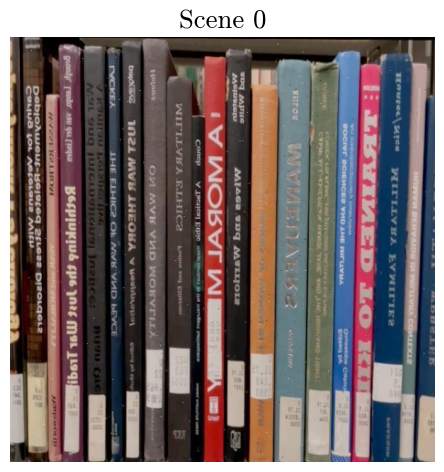

Processing scenes:   3%|▎         | 1/29 [00:05<02:27,  5.26s/it]

Scene 1: 2 books found, total area: 44042 pixels
  Individual areas: [23415, 20627] pixels


/tmp/ipykernel_17010/226203200.py:68: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.subplot(1, len(matches) + 1, i + 2)


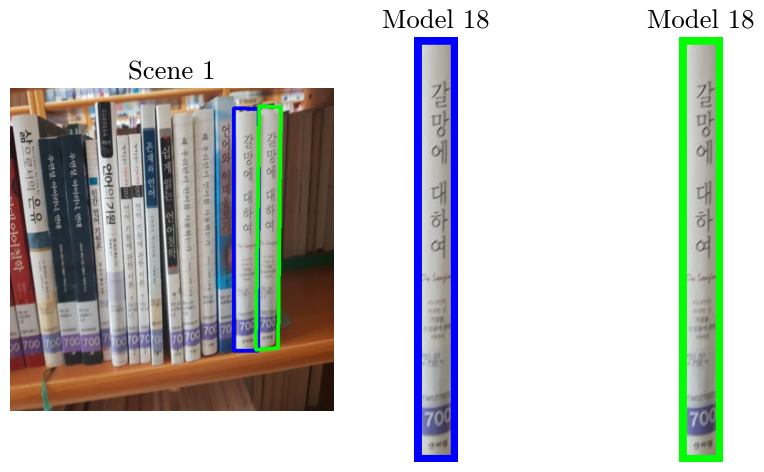

Processing scenes:   7%|▋         | 2/29 [00:09<02:10,  4.84s/it]

Scene 2: 1 books found, total area: 16696 pixels


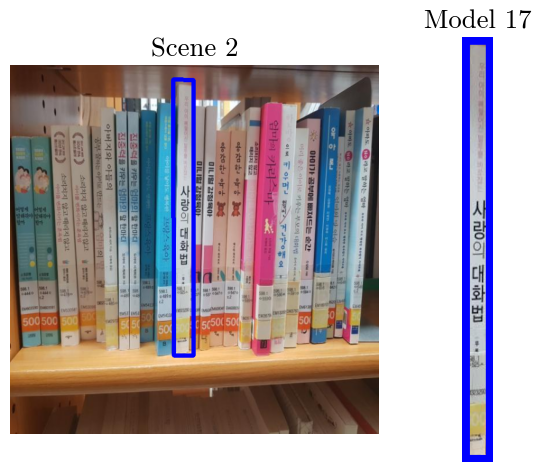

Processing scenes:  10%|█         | 3/29 [00:14<02:02,  4.71s/it]

Scene 3: 2 books found, total area: 31842 pixels
  Individual areas: [16155, 15687] pixels


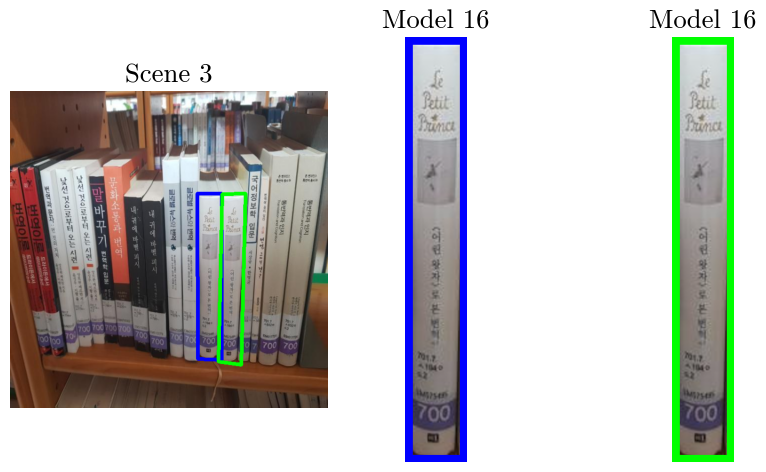

Processing scenes:  14%|█▍        | 4/29 [00:18<01:56,  4.68s/it]

Scene 4: 4 books found, total area: 96755 pixels
  Individual areas: [26605, 25073, 23342, 21734] pixels


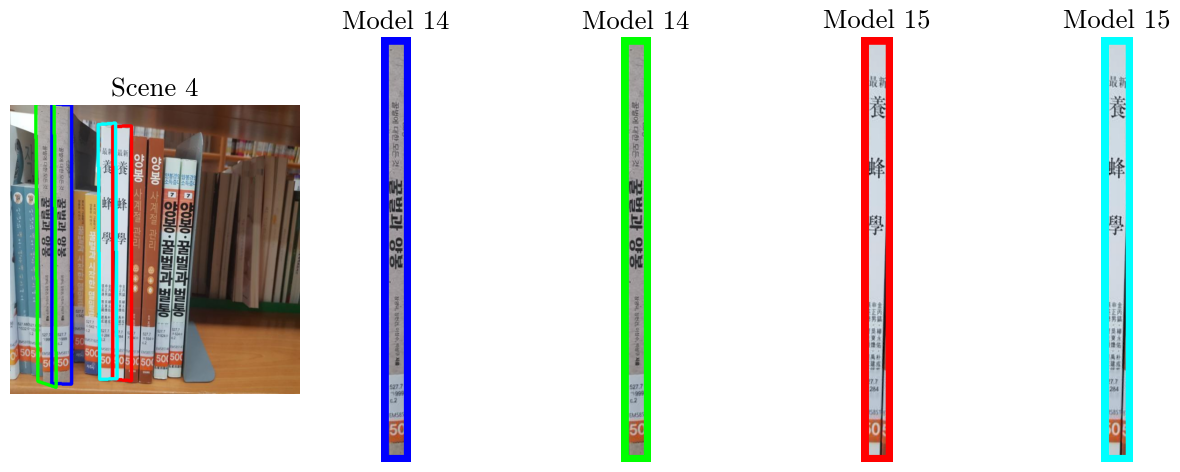

Processing scenes:  17%|█▋        | 5/29 [00:23<01:54,  4.78s/it]

Scene 5: 1 books found, total area: 21879 pixels


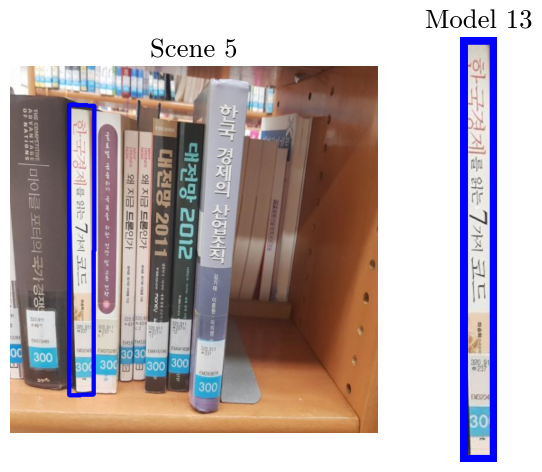

Processing scenes:  21%|██        | 6/29 [00:28<01:46,  4.63s/it]

Scene 6: 1 books found, total area: 26097 pixels


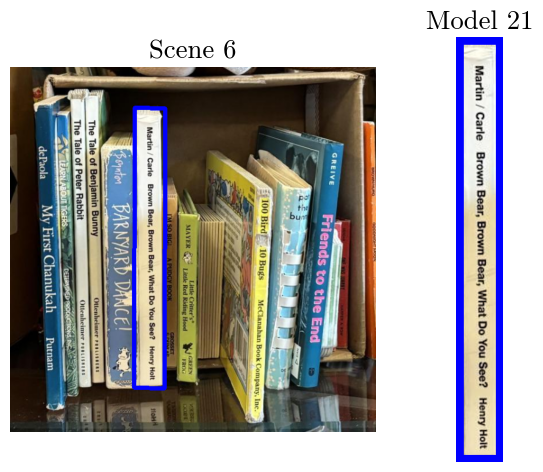

Processing scenes:  24%|██▍       | 7/29 [00:33<01:47,  4.88s/it]

Scene 7: 2 books found, total area: 41163 pixels
  Individual areas: [20283, 20879] pixels


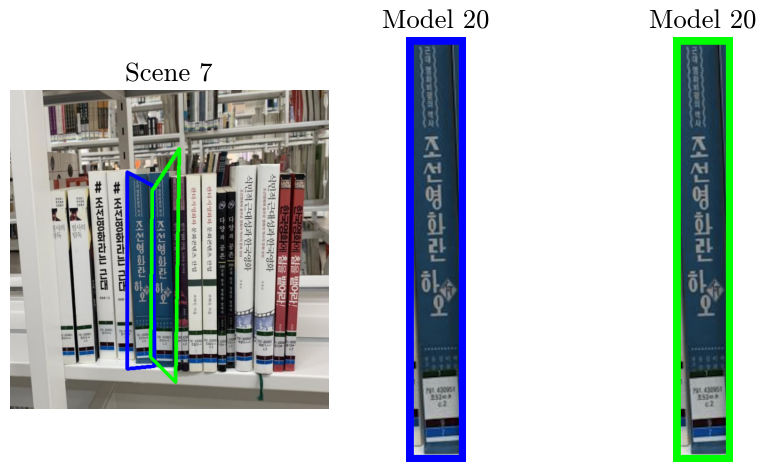

Processing scenes:  28%|██▊       | 8/29 [00:38<01:44,  4.98s/it]

Scene 8: No books found


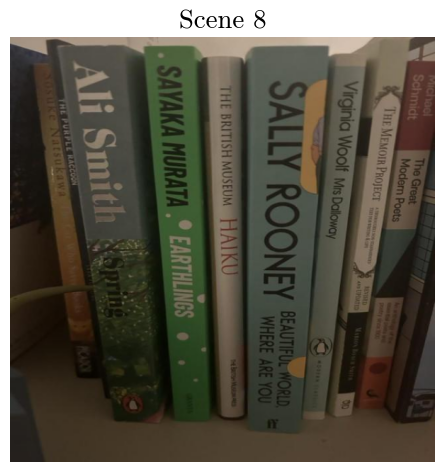

Processing scenes:  31%|███       | 9/29 [00:42<01:34,  4.71s/it]

Scene 9: 1 books found, total area: 8466 pixels


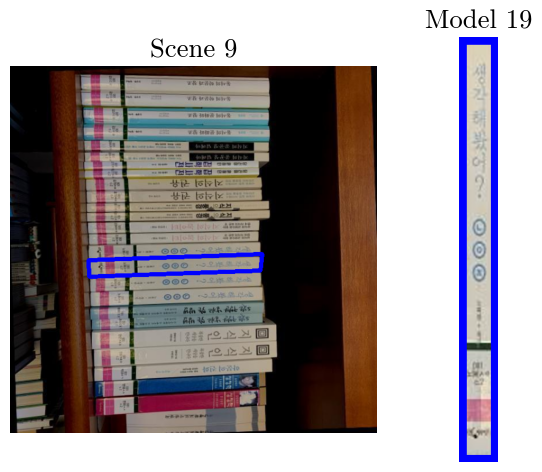

Processing scenes:  34%|███▍      | 10/29 [00:47<01:30,  4.74s/it]

Scene 10: 1 books found, total area: 8447 pixels


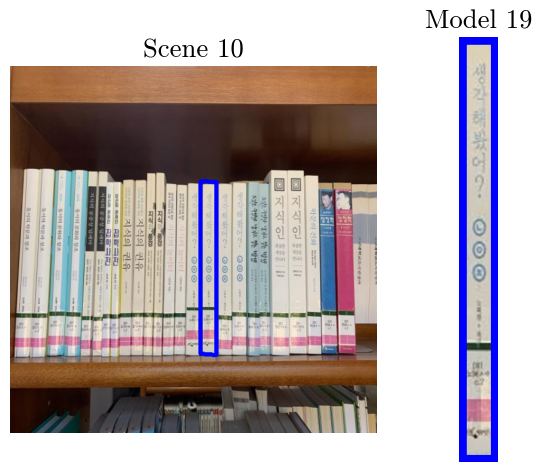

Processing scenes:  38%|███▊      | 11/29 [00:52<01:25,  4.73s/it]

Scene 11: No books found


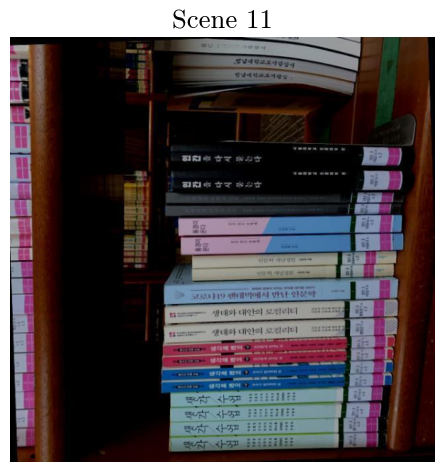

Processing scenes:  41%|████▏     | 12/29 [00:57<01:19,  4.66s/it]

Scene 12: No books found


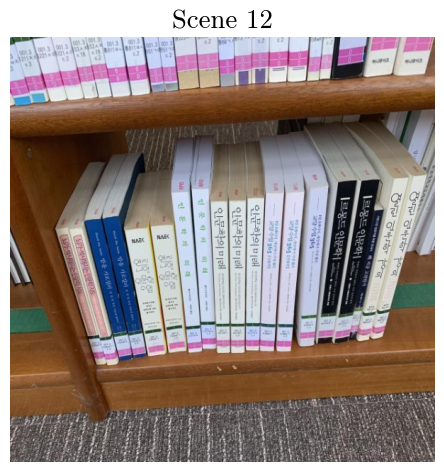

Processing scenes:  45%|████▍     | 13/29 [01:01<01:14,  4.67s/it]

Scene 13: No books found


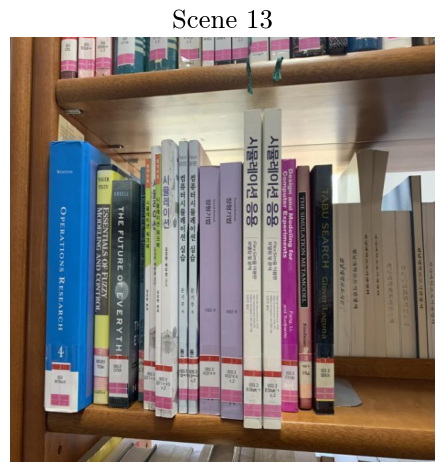

Processing scenes:  48%|████▊     | 14/29 [01:06<01:08,  4.60s/it]

Scene 14: No books found


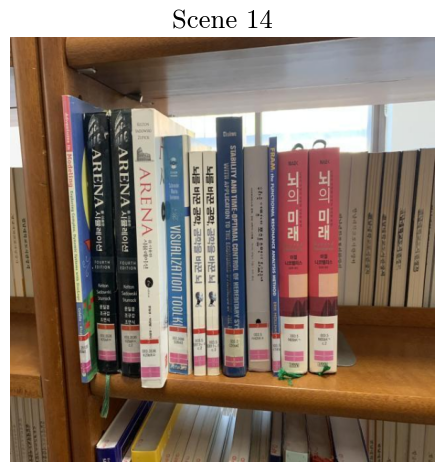

Processing scenes:  52%|█████▏    | 15/29 [01:10<01:03,  4.52s/it]

Scene 15: 2 books found, total area: 23737 pixels
  Individual areas: [14160, 9577] pixels


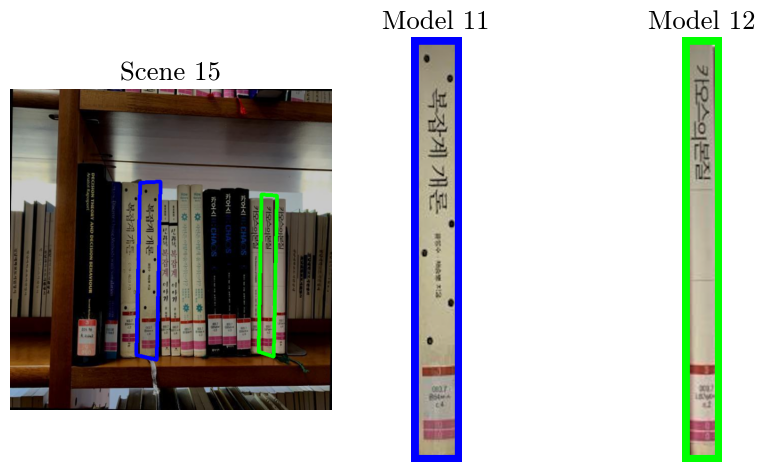

Processing scenes:  55%|█████▌    | 16/29 [01:14<00:58,  4.51s/it]

Scene 16: 2 books found, total area: 23099 pixels
  Individual areas: [13866, 9233] pixels


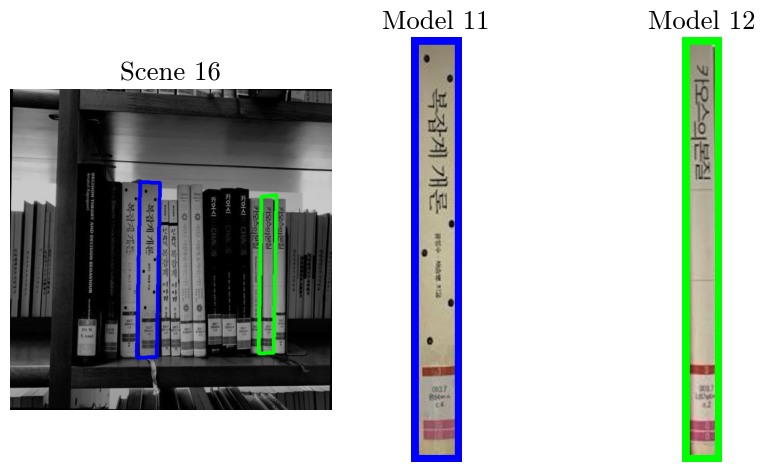

Processing scenes:  59%|█████▊    | 17/29 [01:19<00:54,  4.53s/it]

Scene 17: 2 books found, total area: 22899 pixels
  Individual areas: [13934, 8966] pixels


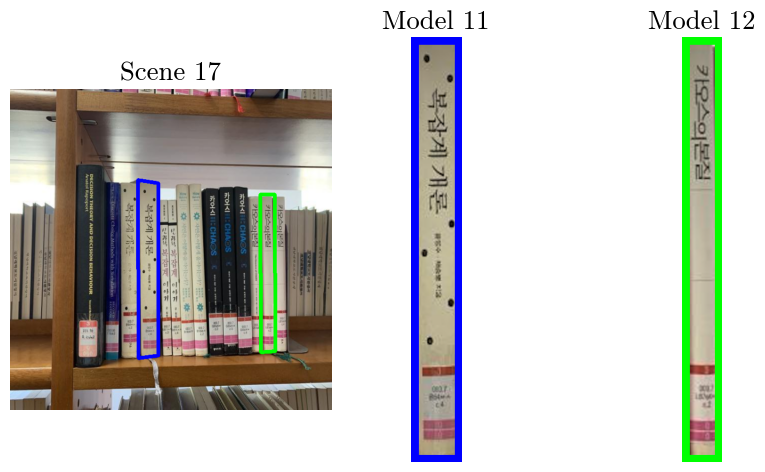

Processing scenes:  62%|██████▏   | 18/29 [01:23<00:49,  4.49s/it]

Scene 18: 6 books found, total area: 78438 pixels
  Individual areas: [11942, 11885, 11306, 16831, 13035, 13438] pixels


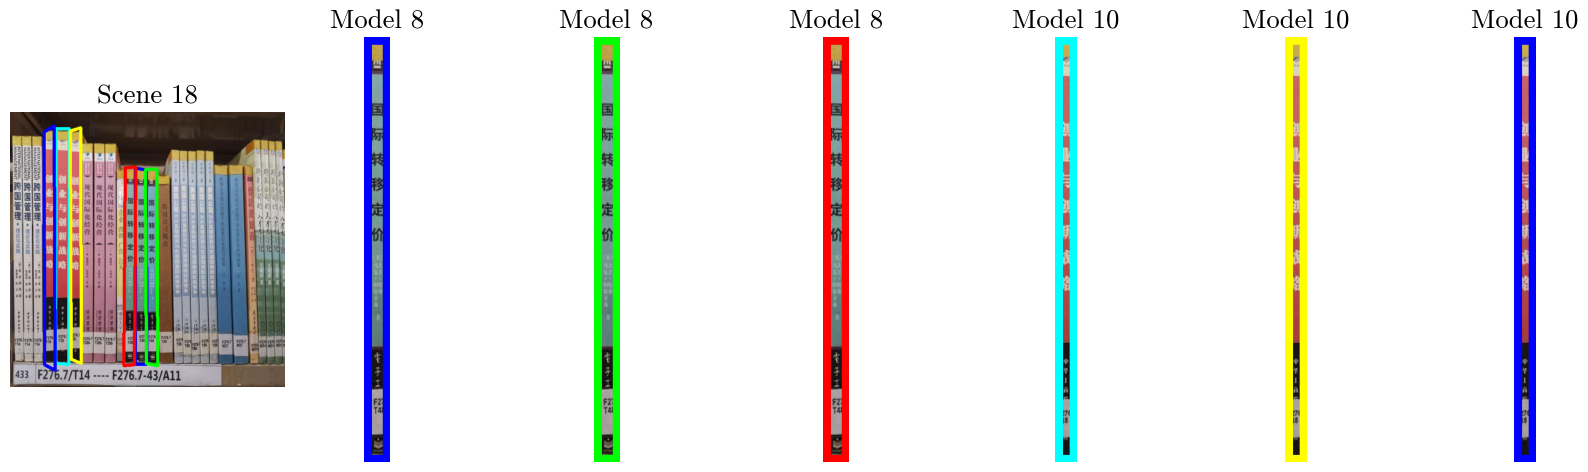

Processing scenes:  66%|██████▌   | 19/29 [01:29<00:48,  4.87s/it]

Scene 19: 3 books found, total area: 50541 pixels
  Individual areas: [14672, 17486, 18382] pixels


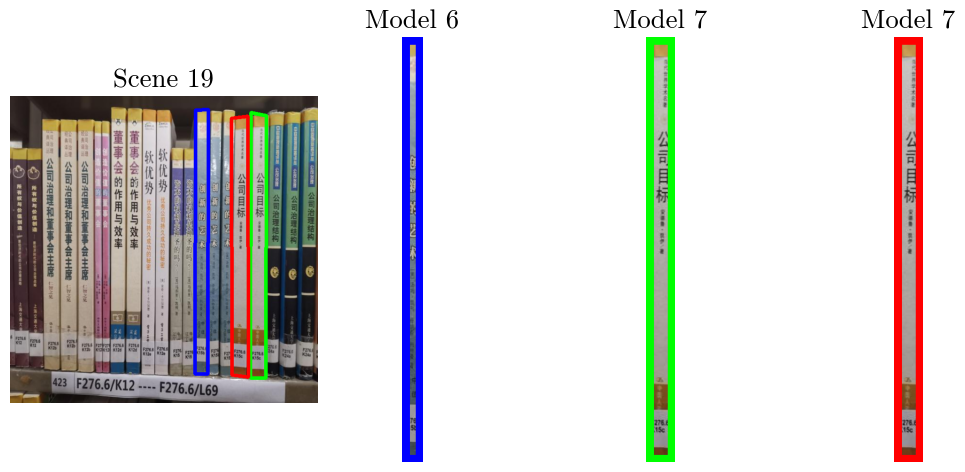

Processing scenes:  69%|██████▉   | 20/29 [01:35<00:46,  5.12s/it]

Scene 20: No books found


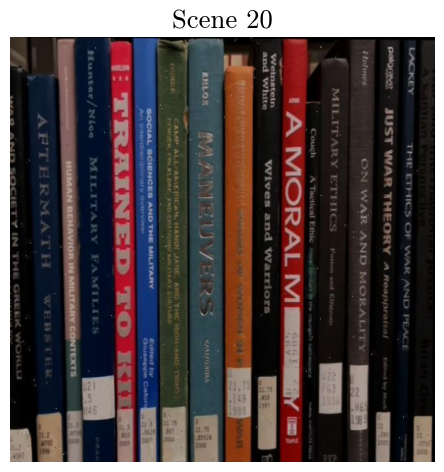

Processing scenes:  72%|███████▏  | 21/29 [01:40<00:40,  5.04s/it]

Scene 21: No books found


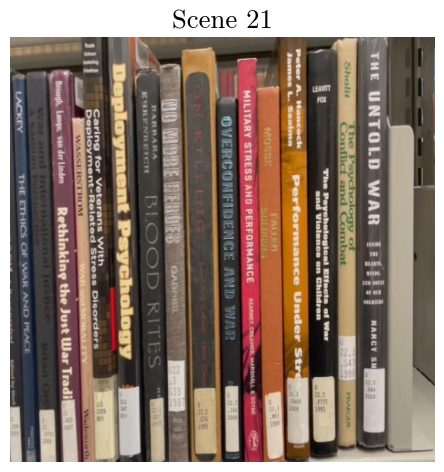

Processing scenes:  76%|███████▌  | 22/29 [01:45<00:36,  5.19s/it]

Scene 22: No books found


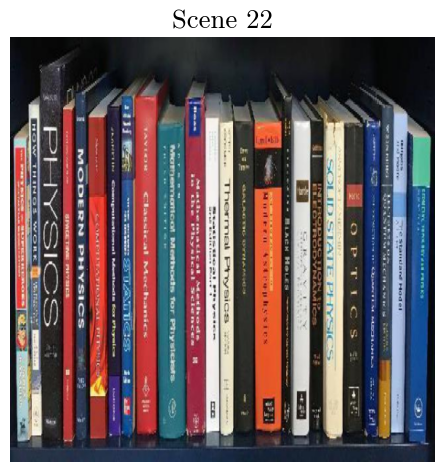

Processing scenes:  79%|███████▉  | 23/29 [01:50<00:30,  5.09s/it]

Scene 23: 1 books found, total area: 20456 pixels


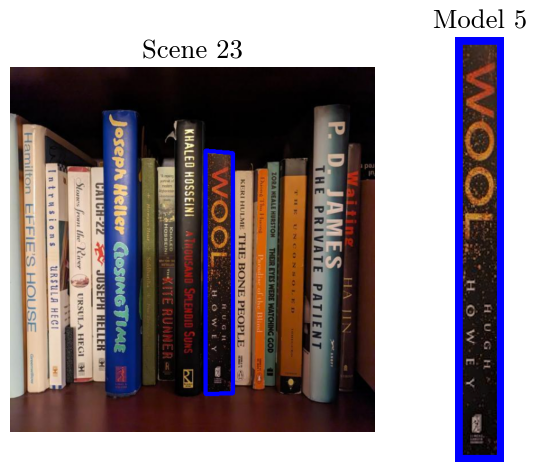

Processing scenes:  83%|████████▎ | 24/29 [01:55<00:24,  4.98s/it]

Scene 24: No books found


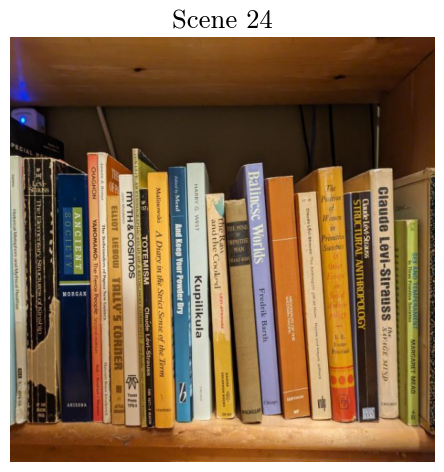

Processing scenes:  86%|████████▌ | 25/29 [01:59<00:19,  4.78s/it]

Scene 25: No books found


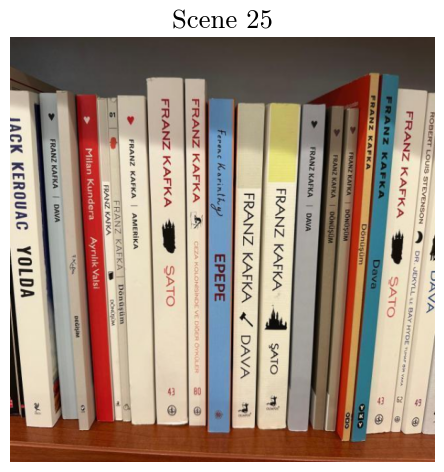

Processing scenes:  90%|████████▉ | 26/29 [02:03<00:13,  4.56s/it]

Scene 26: 3 books found, total area: 90164 pixels
  Individual areas: [13396, 13445, 63323] pixels


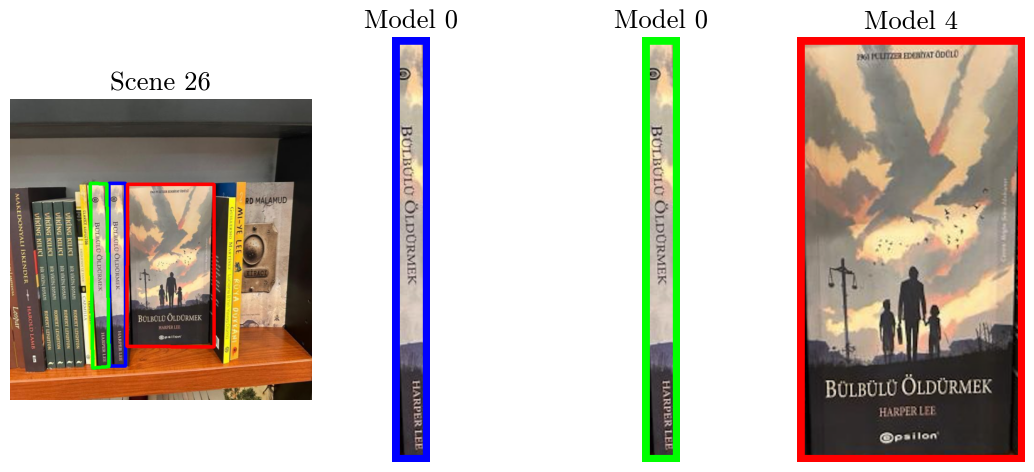

Processing scenes:  93%|█████████▎| 27/29 [02:08<00:09,  4.57s/it]

Scene 27: 2 books found, total area: 39789 pixels
  Individual areas: [18721, 21068] pixels


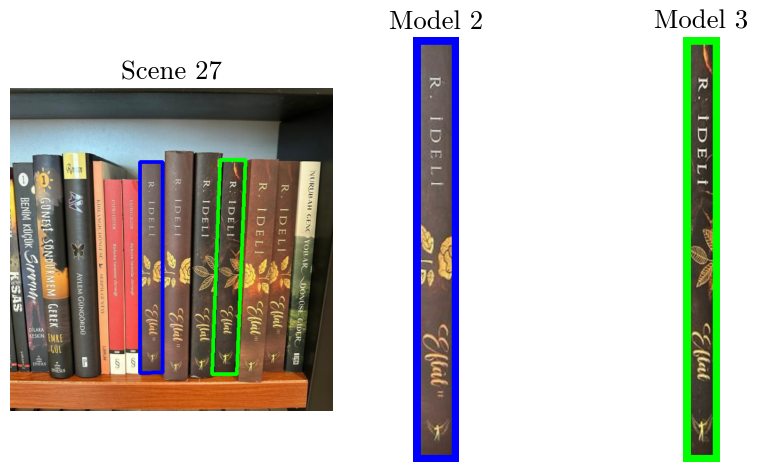

Processing scenes:  97%|█████████▋| 28/29 [02:12<00:04,  4.53s/it]

Scene 28: 2 books found, total area: 16985 pixels
  Individual areas: [8001, 8984] pixels


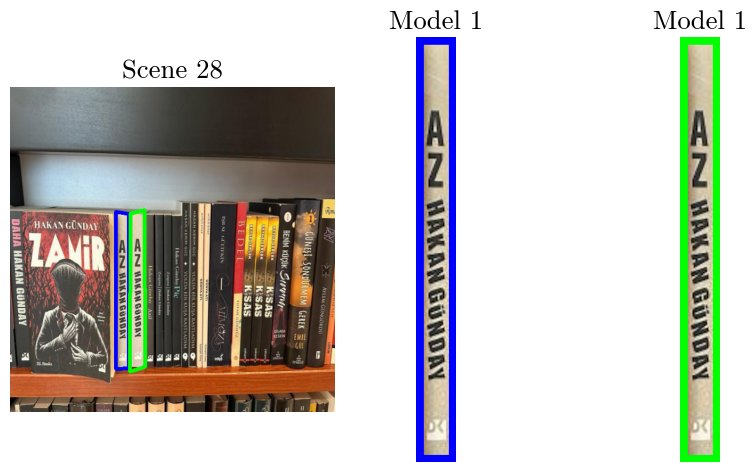

Processing scenes: 100%|██████████| 29/29 [02:17<00:00,  4.73s/it]


=== SUMMARY ===
Total area covered across all scenes: 661494 pixels


In [ ]:
def preprocess_for_sift(gray):
    # Produce an aggressive preprocessing to enhance SIFT performance
    # Apply Gaussian blur to reduce noise and improve keypoint detection
    blurred = cv2.GaussianBlur(gray, (13, 13), 0)
    # Apply histogram equalization to improve contrast
    equalized = cv2.equalizeHist(blurred)
    return equalized


DEBUG = False
total_area_all_scenes = 0  # Aggiungi contatore totale

for SCENE_IDX in tqdm(range(len(scenes_images)), desc="Processing scenes"):
    scenes_image = scenes_images[SCENE_IDX].copy()

    matches = []
    for idx, m in enumerate(models_images):
        model_image = m.copy()

        for i in range(10):
            scene_corners = instance_detect(
                scenes_image,
                model_image,
                preprocess=None,
                plot_matches=DEBUG,
                plot_rectangle=DEBUG,
                plot_descriptors=DEBUG,
                debug=DEBUG,
            )
            is_valid, reason = is_rectangle_valid(scene_corners)
            if DEBUG:
                print(
                    f"Model {idx}, Iteration {i}, Valid: {is_valid}, Reason: {reason}"
                )
            if not is_valid:
                break
            # Mask the detected area in the scene image to find another instance
            mask = np.zeros(scenes_image.shape[:2], dtype=np.uint8)

            matches.append((model_image, scene_corners, idx))
            cv2.fillPoly(mask, [np.int32(scene_corners)], (255))
            scenes_image = cv2.bitwise_and(
                scenes_image, scenes_image, mask=cv2.bitwise_not(mask)
            )

    # AGGIUNGI: Calcola e stampa info aree
    scene_total_area = print_area_info(matches, SCENE_IDX)
    total_area_all_scenes += scene_total_area

    # Mantieni la visualizzazione originale
    plot_detections(scenes_images, matches, SCENE_IDX=SCENE_IDX)

    # break  # Rimuovi o mantieni per testare una sola scena

# AGGIUNGI: Stampa statistiche finali
print(f"\n=== SUMMARY ===")
print(f"Total area covered across all scenes: {total_area_all_scenes:.0f} pixels")

## Evaluation criteria

1. **Clarity and conciseness**. Present your work in a readable way: format your code and comment every important step;

2. **Procedural correctness**. There are several ways to solve the assignment. Design your own sound approach and justify every decision you make;

3. **Correctness of results**. Try to solve as many instances as possible. You should be able to solve all the instances of the assignment, however, a thoroughly justified and sound procedure with a lower number of solved instances will be valued **more** than a poorly designed and justified approach that solves more or all instances.
